In [30]:
import pandas as pd
import numpy as np

In [31]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Path to dataset files: /kaggle/input/creditcardfraud


In [32]:
df=pd.read_csv(path+"/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [33]:
df['Class'].value_counts()

,count
Class,
0,284315
1,492


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [35]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [36]:
fraud=df['Class'].value_counts()[1]/df.shape[0]
print("Fraud Percent:",fraud*100)

Fraud Percent: 0.1727485630620034


In [37]:
leg=df['Class'].value_counts()[0]/df.shape[0]
print("Legitamate Percent:",leg*100)

Legitamate Percent: 99.82725143693798


In [38]:
fraud/leg

np.float64(0.00173047500131896)

<Axes: xlabel='Amount', ylabel='Count'>

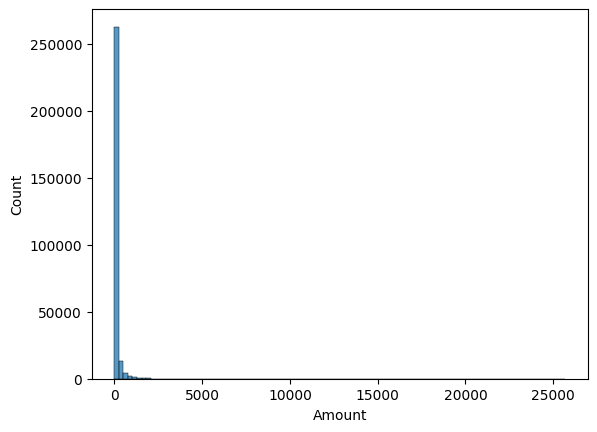

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.histplot(df['Amount'],bins=100)

<Axes: xlabel='Class', ylabel='count'>

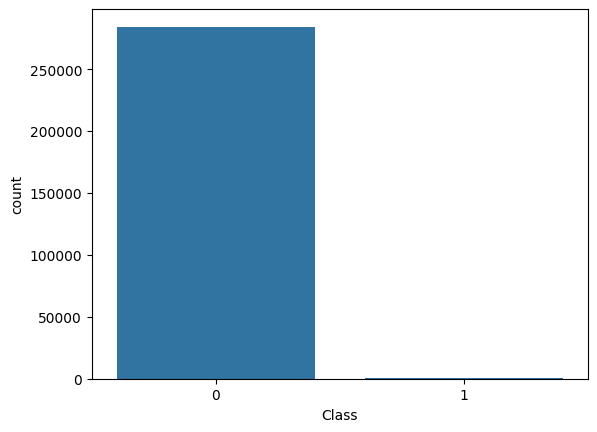

In [40]:
sns.countplot(x='Class',data=df)

<Axes: >

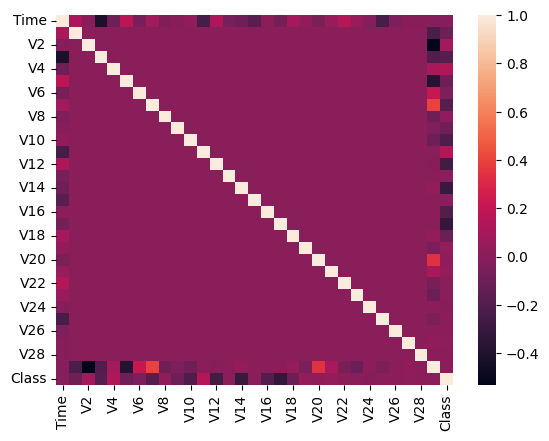

In [41]:
sns.heatmap(df.corr())

In [42]:
from tensorflow.keras.layers import Dense,LSTM,MultiHeadAttention
from tensorflow.keras.models import Sequential
from sklearn.model_selection import train_test_split

In [43]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [44]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
df['Amount']=scaler.fit_transform(df['Amount'].values.reshape(-1,1))

In [45]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.244964,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.342475,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.160686,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.140534,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.073403,0


In [52]:
X=df.drop(['Time','Class'],axis=1)
y=df['Class']

In [46]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape

(227845, 29)

In [47]:
dense=Sequential([
    Dense(128,activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64,activation='relu'),
    Dense(1,activation='sigmoid')
])
dense.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
dense.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │         3,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,161 (47.50 KB)

 Trainable params: 12,161 (47.50 KB)

 Non-trainable params: 0 (0.00 B)

In [48]:
dense.fit(X_train,y_train,epochs=6,validation_data=(X_test,y_test))

Epoch 1/6
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 24s 3ms/step - accuracy: 0.9993 - loss: 0.0052 - val_accuracy: 0.9992 - val_loss: 0.0036
Epoch 2/6
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 23s 3ms/step - accuracy: 0.9993 - loss: 0.0031 - val_accuracy: 0.9995 - val_loss: 0.0044
Epoch 3/6
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 24s 3ms/step - accuracy: 0.9994 - loss: 0.0028 - val_accuracy: 0.9994 - val_loss: 0.0027
Epoch 4/6
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 22s 3ms/step - accuracy: 0.9994 - loss: 0.0026 - val_accuracy: 0.9994 - val_loss: 0.0031
Epoch 5/6
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 22s 3ms/step - accuracy: 0.9994 - loss: 0.0025 - val_accuracy: 0.9994 - val_loss: 0.0028
Epoch 6/6
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 23s 3ms/step - accuracy: 0.9995 - loss: 0.0024 - val_accuracy: 0.9994 - val_loss: 0.0030


In [53]:
test_loss,test_acc=dense.evaluate(X_test,y_test)
print("Test Loss:",test_loss)
print("Test Accuracy:",test_acc)

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9994 - loss: 0.0030
Test Loss: 0.003036229871213436
Test Accuracy: 0.9993680119514465


In [58]:
from tensorflow.keras.layers import Dropout
SEQ_LEN=5
X_seq=[]
y_seq=[]
for i in range(len(X)-SEQ_LEN):
  X_seq.append(X[i:i+SEQ_LEN])
  y_seq.append(y[i+SEQ_LEN])
X_seq=np.array(X_seq)
y_seq=np.array(y_seq)
X_train,X_test,y_train,y_test = train_test_split(
    X_seq,
    y_seq,
    test_size=0.2,
    random_state=42,
    stratify=y_seq
)

In [61]:
lstm=Sequential([
    LSTM(128,input_shape=(X_train.shape[1],X_train.shape[2]),return_sequences=True),
    Dropout((0.2)),
    LSTM(64,return_sequences=False),
    Dropout((0.2)),
    Dense(1)
])
lstm.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
lstm.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_10 (LSTM)                  │ (None, 5, 128)         │        80,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 5, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 130,369 (509.25 KB)

 Trainable params: 130,369 (509.25 KB)

 Non-trainable params: 0 (0.00 B)

In [62]:
lstm.fit(X_train,y_train,epochs=6,validation_data=(X_test,y_test))

Epoch 1/6
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 127s 17ms/step - accuracy: 0.9983 - loss: 0.0279 - val_accuracy: 0.9983 - val_loss: 0.0277
Epoch 2/6
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 121s 17ms/step - accuracy: 0.9983 - loss: 0.0279 - val_accuracy: 0.9983 - val_loss: 0.0277
Epoch 3/6
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 123s 17ms/step - accuracy: 0.9983 - loss: 0.0279 - val_accuracy: 0.9983 - val_loss: 0.0277
Epoch 4/6
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 120s 17ms/step - accuracy: 0.9983 - loss: 0.0279 - val_accuracy: 0.9983 - val_loss: 0.0277
Epoch 5/6
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 119s 17ms/step - accuracy: 0.9983 - loss: 0.0279 - val_accuracy: 0.9983 - val_loss: 0.0277
Epoch 6/6
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 121s 17ms/step - accuracy: 0.9983 - loss: 0.0279 - val_accuracy: 0.9983 - val_loss: 0.0277


In [63]:
test_loss,test_acc=lstm.evaluate(X_test,y_test)
print("Test Loss:",test_loss)
print("Test Accuracy:",test_acc)

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9983 - loss: 0.0277
Test Loss: 0.027730781584978104
Test Accuracy: 0.9982795119285583


In [69]:
from tensorflow.keras.layers import Input,GlobalAveragePooling1D
from tensorflow.keras.models import Model
inputs=Input(shape=(X_train.shape[1],X_train.shape[2]))
lstm_out=LSTM(64,return_sequences=True)(inputs)
att=MultiHeadAttention(num_heads=8,key_dim=64)(lstm_out,lstm_out)
pooled=GlobalAveragePooling1D()(att)
output=Dense(1,activation='sigmoid')(pooled)
model=Model(inputs=inputs,outputs=output)
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_12      │ (None, 5, 29)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_16 (LSTM)      │ (None, 5, 64)     │     24,064 │ input_layer_12[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 5, 64)     │    132,672 │ lstm_16[0][0],    │
│ (MultiHeadAttentio… │                   │            │ lstm_16[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ multi_head_atten… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 1)         │         65 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 156,801 (612.50 KB)

 Trainable params: 156,801 (612.50 KB)

 Non-trainable params: 0 (0.00 B)

In [70]:
model.fit(X_train,y_train,epochs=6,validation_data=(X_test,y_test))

Epoch 1/6
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 313s 44ms/step - accuracy: 0.9982 - loss: 0.0145 - val_accuracy: 0.9982 - val_loss: 0.0122
Epoch 2/6
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 308s 43ms/step - accuracy: 0.9982 - loss: 0.0127 - val_accuracy: 0.9983 - val_loss: 0.0121
Epoch 3/6
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 305s 43ms/step - accuracy: 0.9983 - loss: 0.0123 - val_accuracy: 0.9983 - val_loss: 0.0141
Epoch 4/6
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 305s 43ms/step - accuracy: 0.9983 - loss: 0.0120 - val_accuracy: 0.9983 - val_loss: 0.0120
Epoch 5/6
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 309s 43ms/step - accuracy: 0.9983 - loss: 0.0116 - val_accuracy: 0.9983 - val_loss: 0.0127
Epoch 6/6
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 310s 44ms/step - accuracy: 0.9983 - loss: 0.0106 - val_accuracy: 0.9983 - val_loss: 0.0128


In [71]:
test_loss,test_acc=model.evaluate(X_test,y_test)
print("Test Loss:",test_loss)
print("Test Accuracy:",test_acc)

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.9983 - loss: 0.0128
Test Loss: 0.012770339846611023
Test Accuracy: 0.9982795119285583
